## **Experimental Study of Spatial Diversity Using Dual RTL-SDR for FM Signals**

In this project, envelope data captured simultaneously from two spatially separated RTL-SDR receivers tuned to a commercial FM broadcast channel (93.5 MHz) is processed to characterize and exploit **spatial diversity**: Envelope Extraction, Branch Decorrelation, Selection Combining (SC), Equal Gain Combining (EGC), Outage Probability, Diversity Gain (measured vs. theoretical Rayleigh), SNR Margin, Level Crossing Rate (LCR), and Average Fade Duration (AFD).

## Hardware Setup and Data Collection

**Hardware:**
- Two RTL-SDR dongles (RTL2832U-based), one per diversity branch, both connected to a single Windows laptop.
- Branch 0 (SDR0) placed **indoors**; Branch 1 (SDR1) placed **near a window**, ~1.5–2 m apart, to promote spatial decorrelation between branches.

**Signal chain (GNU Radio Companion):**
1. Both RTL-SDRs simultaneously capture complex baseband IQ samples at **2.4 MSPS**, tuned to **93.5 MHz**
2. Each IQ stream is decimated by **100×** (2.4 MSPS → 24 kSPS) to reduce data rate while still resolving the slow, spatially-driven fading (audio-rate FM content is not of interest here)
3. Instantaneous power is computed as $|x[n]|^2$ from the decimated IQ samples, independently on each branch
4. The resulting per-branch power streams are logged to raw binary .bin files (float32, no header)
5. A separate dead-frequency capture is taken on each branch for noise-floor / SNR reference

**Data collection procedure:**
- Both receivers were held **static** for the entire run, so the observed fading reflects slow environmental changes rather than Doppler/motion effects
- A single simultaneous run of **~96 s** was recorded on both branches (diversity_SDR0.bin, diversity_SDR1.bin), plus short noise-floor captures on each branch (noise_SDR0.bin, noise_SDR1.bin) at its final operating gain
- Branch 0 (indoor) used gain = 40, Branch 1 (window) used gain = 30, set independently — the indoor branch needed the extra 10 dB to clear the noise floor, verified via the noise-floor capture and direct audio listening at gain 30 (FM audio was nearly inaudible). This gain offset is corrected for numerically later in the notebook.
- Gain and tuned frequency were held fixed within each branch for the full run, so branch statistics are directly comparable after the gain-offset correction

The rest of this notebook works entirely from these logged .bin files.

In [ ]:
# Mount Google Drive to access the raw .bin captures recorded via GNU Radio.
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


## Imports and Parameters

- fs_env: envelope sample rate after the GNU Radio flowgraph decimates the raw 2.4 MSPS IQ capture by 100×. Only instantaneous power (envelope), not audio, is needed here, so 24 kSPS is more than enough to resolve the fading dynamics of interest.
- eps: a small numerical floor added before log10() calls to avoid log10(0) for zero or near-zero power samples.
- trim_sec: seconds of startup transient discarded from the beginning of each capture.

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
from scipy.stats import linregress
import warnings
warnings.filterwarnings("ignore")

folder = '/content/drive/MyDrive/Colab Notebooks/FM_Diversity'

fs_env = 2.4e6 / 100
eps = 1e-12
trim_sec = 1

## Load, trim, and align captures

Loads the two signal captures (diversity_SDR0/1.bin) and the two dead-frequency noise captures used later for SNR estimation. The first ~1 s of each signal capture is dropped to remove startup transients, and both branches are truncated to a common length to compensate for the small clock-rate mismatch between the two independently clocked RTL-SDRs (they are not sample-clock synchronized).

**Gain correction:** Branch 0 (indoor) was captured at receiver gain = 40 dB while Branch 1 (window) was captured at gain = 30 dB, because the indoor branch needed the extra gain to clear the noise floor. To make the two branches' power values directly comparable, Branch 0's dB values are shifted down by the 10 dB gain difference (-10), effectively expressing it on the same 30 dB-gain scale as Branch 1, before any further analysis.

Usable duration after trim: 95.17 sec


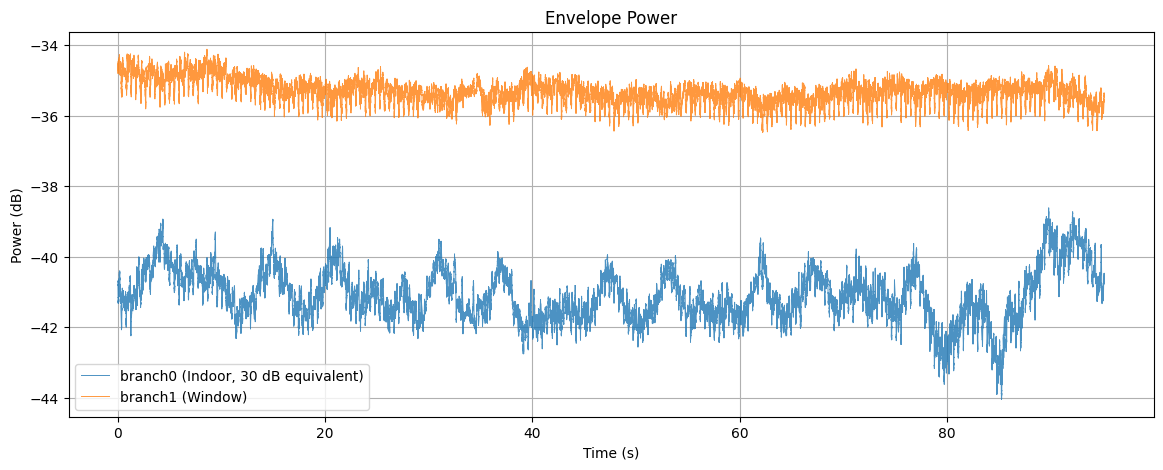

In [ ]:
# Indoor samples: captured at 40 dB
branch0 = np.fromfile(f'{folder}/diversity_SDR0.bin', dtype=np.float32)

# Window samples: captured at 30 dB
branch1 = np.fromfile(f'{folder}/diversity_SDR1.bin', dtype=np.float32)

# Noise floor samples (dead-frequency captures, used later for SNR margin)
noise0  = np.fromfile(f'{folder}/noise_SDR0.bin', dtype=np.float32)
noise1  = np.fromfile(f'{folder}/noise_SDR1.bin', dtype=np.float32)

# Trim startup transient
trim_samples = int(trim_sec * fs_env)
branch0 = branch0[trim_samples:]
branch1 = branch1[trim_samples:]

# Match lengths (SDR dongles aren't clock-synced)
min_len = min(len(branch0), len(branch1))
b0_raw = branch0[:min_len]   # raw, gain=40
b1     = branch1[:min_len]   # raw, gain=30
t = np.arange(min_len) / fs_env

print(f"Usable duration after trim: {min_len/fs_env:.2f} sec")

# Gain-equalize Branch 0 to Branch 1's 30 dB reference in the LINEAR domain
b0 = b0_raw / 10.0

b0_dB = 10 * np.log10(b0 + eps)   # gain-equalized, 30 dB-equivalent
b1_dB = 10 * np.log10(b1 + eps)

# Plot Envelope Power
plt.figure(figsize=(14, 5))
plt.plot(t, b0_dB, label='branch0 (Indoor, 30 dB equivalent)', alpha=0.8, linewidth=0.7)
plt.plot(t, b1_dB, label='branch1 (Window)', alpha=0.8, linewidth=0.7)
plt.xlabel('Time (s)')
plt.ylabel('Power (dB)')
plt.title('Envelope Power')
plt.legend()
plt.grid(True)
plt.show()

**Result:** Branch 0 (indoor) shows deeper fades than Branch 1 (window), including a pronounced dip around $t \approx 80$–$87$ s with no matching dip in Branch 1. This suggests the two branches fade semi-independently, which is confirmed quantitatively below.


## Diversity combining: Selection (SC) and Equal Gain (EGC)

Combines the two aligned linear-power streams $p_0[n]$, $p_1[n]$ sample-by-sample:

$$p_{SC}[n] = \max(p_0[n], p_1[n]), \qquad p_{EGC}[n] = \left(\sqrt{p_0[n]} + \sqrt{p_1[n]}\right)^2$$

SC just picks the stronger branch at each instant. EGC coherently sums the branch amplitudes — but since only power (not phase) was captured, this assumes ideal co-phasing and is therefore a **best-case upper bound** on EGC performance; a real non-coherent implementation with unsynchronized receivers would lose some of this gain to phase mismatch.

In [ ]:
# Selection Combining
combined_SC = np.maximum(b0, b1)

# EGC approximation: phase information is unavailable.
# We assume perfect phase alignment and combine the branch amplitudes.
combined_EGC = (np.sqrt(b0) + np.sqrt(b1)) ** 2

SC_dB  = 10 * np.log10(combined_SC + eps)
EGC_dB = 10 * np.log10(combined_EGC + eps)

print("Mean power (dB):")
print(f"  Branch0 (no diversity): {b0_dB.mean():.2f}")
print(f"  Branch1 (no diversity): {b1_dB.mean():.2f}")
print(f"  SC combined:            {SC_dB.mean():.2f}")
print(f"  EGC combined:           {EGC_dB.mean():.2f}")

Mean power (dB):
  Branch0 (no diversity): -41.09
  Branch1 (no diversity): -35.33
  SC combined:            -35.33
  EGC combined:           -31.71


**Result**: Branch 1 (window) is the stronger branch on average (−35.33 dB vs. Branch 0's −41.09 dB). SC's mean power (−35.33 dB) matches Branch 1's almost exactly, since Branch 1 stays stronger for most of the capture and SC selects it on nearly every sample. EGC's mean power (−31.71 dB) is higher than either single branch, since it coherently sums both branch amplitudes on every sample rather than switching between them.


## 1% Outage Threshold and Diversity Gain

The 1%-outage threshold is found by sorting all power samples and reading off the value at the 1st percentile — i.e. the power level the signal only drops below 1% of the time. It measures how bad the worst moments are, which matters more for reliability than average power.

Diversity gain compares this threshold for a combiner (SC or EGC) against the **better** of the two single branches: gain = (combiner's 1%-outage threshold) − (best single branch's 1%-outage threshold). A positive gain means combining pushed the reliability floor higher than any single antenna could achieve alone; 0 dB means combining bought no improvement at that outage level.

In [ ]:
target_outage = 1.0  # %

def abs_threshold_at_outage(power_dB, target_pct):
    sorted_p = np.sort(power_dB)
    idx = int(len(sorted_p) * target_pct / 100)
    return sorted_p[idx]

th_b0  = abs_threshold_at_outage(b0_dB, target_outage)
th_b1  = abs_threshold_at_outage(b1_dB, target_outage)
th_SC  = abs_threshold_at_outage(SC_dB, target_outage)
th_EGC = abs_threshold_at_outage(EGC_dB, target_outage)

best_single = max(th_b0, th_b1)

gain_SC  = th_SC  - best_single
gain_EGC = th_EGC - best_single

print(f"Power level at {target_outage}% outage:")
print(f"  Branch0: {th_b0:.2f} dB")
print(f"  Branch1: {th_b1:.2f} dB")
print(f"  SC:      {th_SC:.2f} dB")
print(f"  EGC:     {th_EGC:.2f} dB")
print()
print(f"SC diversity gain:  {gain_SC:.2f} dB")
print(f"EGC diversity gain: {gain_EGC:.2f} dB")

Power level at 1.0% outage:
  Branch0: -42.93 dB
  Branch1: -36.14 dB
  SC:      -36.14 dB
  EGC:     -32.59 dB

SC diversity gain:  0.00 dB
EGC diversity gain: 3.55 dB


**Result**: SC gain ≈ 0.00 dB, EGC gain ≈ 3.55 dB. SC's threshold (−36.14 dB) exactly matches Branch 1's, meaning Branch 1 stays ahead of Branch 0 consistently enough that SC never gains anything beyond just picking the better branch. EGC still delivers a real gain by combining both branches on every sample rather than switching. SC provides no diversity gain here; EGC provides a smaller but still real one.


## Measured vs Theoretical Diversity Gain

Two checks against theory:
1. **Branch correlation**: Pearson correlation of the dB-domain envelope power between branches. Below ~0.5 conventionally indicates enough spatial decorrelation for diversity to help.
2. **Rayleigh simulation**: closed-form SC/EGC outage expressions don't exist for branches with unequal means, so two independent Rayleigh-faded branches (exponential instantaneous power) are simulated using the measured branch means, and the same SC/EGC/outage pipeline is applied. This gives the expected diversity gain under ideal i.i.d. Rayleigh fading, as a benchmark for the measured result.

In [ ]:
# Lower correlation between branches indicates more independent fading.
correlation = np.corrcoef(b0, b1)[0, 1]
print(f"Measured branch correlation: {correlation:.3f}")

# Rayleigh-fading theoretical simulation
np.random.seed(42)
N = 500000

sim_p0 = np.random.exponential(b0.mean(), N)
sim_p1 = np.random.exponential(b1.mean(), N)

# Apply SC and EGC to the simulated branches
sim_SC = np.maximum(sim_p0, sim_p1)
sim_EGC = (np.sqrt(sim_p0) + np.sqrt(sim_p1))**2

sim_SC_dB = 10*np.log10(sim_SC + eps)
sim_EGC_dB = 10*np.log10(sim_EGC + eps)

th_sim_SC = abs_threshold_at_outage(sim_SC_dB, target_outage)
th_sim_EGC = abs_threshold_at_outage(sim_EGC_dB, target_outage)

best_sim_single = max(
    abs_threshold_at_outage(10*np.log10(sim_p0 + eps), target_outage),
    abs_threshold_at_outage(10*np.log10(sim_p1 + eps), target_outage)
)

theory_gain_SC = th_sim_SC - best_sim_single
theory_gain_EGC = th_sim_EGC - best_sim_single

# Compare theoretical Rayleigh diversity gains with the measured gains
print(f"Theoretical SC gain:  {theory_gain_SC:.2f} dB")
print(f"Theoretical EGC gain: {theory_gain_EGC:.2f} dB")
print(f"Measured SC gain:     {gain_SC:.2f} dB")
print(f"Measured EGC gain:    {gain_EGC:.2f} dB")

Measured branch correlation: 0.274
Theoretical SC gain:  7.51 dB
Theoretical EGC gain: 11.39 dB
Measured SC gain:     0.00 dB
Measured EGC gain:    3.55 dB


**Result:** measured correlation ρ ≈ 0.274 — below the 0.5 threshold, indicating decorrelation but not independence. Theory (i.i.d. Rayleigh, same means) predicts 7.51 dB (SC) and 11.39 dB (EGC); measured gains are only 0.00 dB and 3.55 dB. Two effects explain the gap:

- **No branch crossover during Branch 1's deep fades:** SC's outage threshold exactly matches Branch 1's, meaning Branch 0 was never stronger than Branch 1 at Branch 1's own worst 1% of moments — so max(b0, b1) reduces to just b1 there, and SC captures none of its theoretical gain.
- **Correlated, slow fading:** with ρ=0.274 (not 0) and static receivers producing slow, environment-driven fading rather than fast Rayleigh fading, the branches don't decorrelate enough or fast enough to match the i.i.d. simulation. EGC, which doesn't need crossover to benefit, still realizes about a third of its theoretical gain.

### SNR Margin vs Noise Floor

Uses the dedicated dead-frequency noise captures (noise0, noise1), each taken at its branch's actual operating gain (40 for Branch 0, 30 for Branch 1) — same as the raw signal captures.

**Note on the gain correction:** the −10 dB shift applied earlier to get b0_dB exists only to make Branch 0 and Branch 1 comparable to each other. It should **not** be used here, since noise0 was never shifted — SNR margin is a within-branch comparison (signal vs. its own noise floor, same gain), so the shift would cancel out incorrectly and understate Branch 0's margin by 10 dB. The raw, unshifted Branch 0 power (b0_dB_raw) is used instead, matching the gain at which noise0 was captured.

In [ ]:
noise0_mean_dB = 10 * np.log10(np.mean(noise0) + eps)
noise1_mean_dB = 10 * np.log10(np.mean(noise1) + eps)

b0_raw_dB = 10 * np.log10(b0_raw + eps)   # raw gain-40, matches noise0's gain

snr_b0 = b0_raw_dB.mean() - noise0_mean_dB
snr_b1 = b1_dB.mean() - noise1_mean_dB

print(f"Branch0 (indoor):")
print(f"  Noise floor: {noise0_mean_dB:.2f} dB")
print(f"  Signal mean: {b0_raw_dB.mean():.2f} dB")
print(f"  SNR margin:  {snr_b0:.2f} dB")
print()
print(f"Branch1 (window):")
print(f"  Noise floor: {noise1_mean_dB:.2f} dB")
print(f"  Signal mean: {b1_dB.mean():.2f} dB")
print(f"  SNR margin:  {snr_b1:.2f} dB")

Branch0 (indoor):
  Noise floor: -37.64 dB
  Signal mean: -31.09 dB
  SNR margin:  6.55 dB

Branch1 (window):
  Noise floor: -48.21 dB
  Signal mean: -35.33 dB
  SNR margin:  12.89 dB


**Result:** Branch 0 (indoor) SNR margin ≈ 6.55 dB (noise floor −37.64 dB, signal mean −31.09 dB); Branch 1 (window) SNR margin ≈ 12.89 dB (noise floor −48.21 dB, signal mean −35.33 dB). The indoor branch's smaller margin is consistent with real building-penetration loss, corroborated by a direct audio listening test at that location (FM audio nearly inaudible before the gain was raised from 30→40). Branch 1's healthy margin confirms it reflects a genuinely strong path, not noise-floor compression.


## Level Crossing Rate (LCR) and Average Fade Duration (AFD)

- **LCR** — rate at which the envelope crosses the threshold in the positive (upward) direction, in crossings/s. Higher LCR means the signal fades in and out of that level more often, indicating faster fading dynamics.
- **AFD** — average duration spent below the threshold per fade event, in ms. Longer AFD means fades linger once they occur, even if they aren't necessarily deep.

Together, LCR and AFD describe *how often* fades happen and *how long* they last — complementary to fade depth and outage probability, which describe *how severe* fades are.

In [ ]:
def lcr_afd(power_dB, mean_dB, fs=fs_env):
    envelope_norm = 10 ** ((power_dB - mean_dB) / 20)  # normalized amplitude, mean=1
    threshold = 1.0

    crossings = np.sum((envelope_norm[:-1] < threshold) & (envelope_norm[1:] >= threshold))
    lcr = crossings / (len(envelope_norm) / fs)  # crossings per second

    below = envelope_norm < threshold
    fade_runs, count = [], 0
    for b in below:
        if b:
            count += 1
        else:
            if count > 0:
                fade_runs.append(count)
            count = 0
    afd_samples = np.mean(fade_runs) if fade_runs else 0
    afd_sec = afd_samples / fs

    return lcr, afd_sec


lcr_b0,  afd_b0  = lcr_afd(b0_dB,  b0_dB.mean())
lcr_b1,  afd_b1  = lcr_afd(b1_dB,  b1_dB.mean())
lcr_SC,  afd_SC  = lcr_afd(SC_dB,  SC_dB.mean())
lcr_EGC, afd_EGC = lcr_afd(EGC_dB, EGC_dB.mean())

results = [
    ('Branch0', lcr_b0,  afd_b0),
    ('Branch1', lcr_b1,  afd_b1),
    ('SC',      lcr_SC,  afd_SC),
    ('EGC',     lcr_EGC, afd_EGC),
]

for label, lcr, afd in results:
    print(f"{label:<8s}: LCR = {lcr:6.3f} crossings/s, AFD = {afd*1000:6.1f} ms")

Branch0 : LCR = 15.540 crossings/s, AFD =   34.0 ms
Branch1 : LCR = 27.518 crossings/s, AFD =   17.7 ms
SC      : LCR = 27.518 crossings/s, AFD =   17.7 ms
EGC     : LCR = 21.140 crossings/s, AFD =   24.7 ms


Result: SC's LCR/AFD (27.52/s, 17.7 ms) exactly match Branch 1's — SC tracks Branch 1 for most of the capture, consistent with earlier results. EGC's LCR/AFD (21.14/s, 24.7 ms) sit between the two branches, reflecting its continuous blend of both signals rather than switching to one.

## Summary

Collects Mean Power, SNR Margin, Max Fade Depth, 1%-Outage Threshold, Diversity Gain, LCR, and AFD for both branches and both combiners into one table, plus a side-by-side comparison of measured vs. theoretical (i.i.d. Rayleigh) Diversity Gain.

In [ ]:
summary = pd.DataFrame({
    'Metric': [
        'Mean power (dB)',
        'SNR margin vs noise floor (dB)',
        'Max fade depth (dB, peak-to-trough)',
        'Outage threshold @ 1% outage (absolute dB)',
        'Diversity gain vs best single branch @ 1% outage (dB)',
        'LCR (crossings/s, own-mean threshold)',
        'AFD (ms, own-mean threshold)',
    ],
    'Branch0 (indoor, 30 dB-equiv)': [
        f"{b0_dB.mean():.2f}", f"{snr_b0:.2f}", f"{b0_dB.max()-b0_dB.min():.2f}",
        f"{th_b0:.2f}", "-", f"{lcr_b0:.2f}", f"{afd_b0*1000:.1f}",
    ],
    'Branch1 (window, gain=30)': [
        f"{b1_dB.mean():.2f}", f"{snr_b1:.2f}", f"{b1_dB.max()-b1_dB.min():.2f}",
        f"{th_b1:.2f}", "-", f"{lcr_b1:.2f}", f"{afd_b1*1000:.1f}",
    ],
    'SC (combined)': [
        f"{SC_dB.mean():.2f}", "-", f"{SC_dB.max()-SC_dB.min():.2f}",
        f"{th_SC:.2f}", f"{gain_SC:.2f}", f"{lcr_SC:.2f}", f"{afd_SC*1000:.1f}",
    ],
    'EGC (combined)': [
        f"{EGC_dB.mean():.2f}", "-", f"{EGC_dB.max()-EGC_dB.min():.2f}",
        f"{th_EGC:.2f}", f"{gain_EGC:.2f}", f"{lcr_EGC:.2f}", f"{afd_EGC*1000:.1f}",
    ],
})
print(summary.to_string(index=False))

gain_compare = pd.DataFrame({
    'Combiner': ['SC', 'EGC'],
    'Measured gain (dB)': [gain_SC, gain_EGC],
    'Theoretical gain (dB, IID Rayleigh)': [theory_gain_SC, theory_gain_EGC],
})
print()
print(gain_compare.to_string(index=False))

print()
print(f"Branch correlation (rho): {correlation:.3f}")

                                               Metric Branch0 (indoor, 30 dB-equiv) Branch1 (window, gain=30) SC (combined) EGC (combined)
                                      Mean power (dB)                        -41.09                    -35.33        -35.33         -31.71
                       SNR margin vs noise floor (dB)                          6.55                     12.89             -              -
                  Max fade depth (dB, peak-to-trough)                          5.42                      2.36          2.36           2.64
           Outage threshold @ 1% outage (absolute dB)                        -42.93                    -36.14        -36.14         -32.59
Diversity gain vs best single branch @ 1% outage (dB)                             -                         -          0.00           3.55
                LCR (crossings/s, own-mean threshold)                         15.54                     27.52         27.52          21.14
                         AF

## Results, Interpretation, and Conclusions

**Decorrelation:** ρ=0.274 (< 0.5) — meaningful decorrelation, not full independence.

**Diversity gain:** SC = 0.00 dB, EGC = 3.55 dB. SC gains nothing since Branch 1 stays ahead of Branch 0 through its own worst moments — no crossover. EGC still gains by combining both branches every sample. **Only EGC delivers real benefit here.**

**Vs. theory:** Rayleigh theory predicts 7.51 dB (SC), 11.39 dB (EGC) — both well above measured. Gap due to branch correlation and slow, static-receiver fading. SC is hit hardest since it needs crossover; EGC doesn't.

**SNR:** Branch 0 = 6.55 dB, Branch 1 = 12.89 dB — consistent with indoor penetration loss.

**LCR/AFD:** SC matches Branch 1 exactly (tracks it throughout); EGC sits between both branches.

**Limitations:** EGC is an idealized, perfectly co-phased upper bound; outage stats assume independent samples despite correlated fading; diversity-order estimation invalid (fades too shallow); single ~96 s capture in one environment.

**Bottom line:** low-cost dual RTL-SDR diversity shows a real gain only with EGC — SC gave none since Branch 1 dominated throughout. The gap from Rayleigh theory is mainly due to branch correlation and slow fading.